<a href="https://colab.research.google.com/github/naqirraza99/CS-351L---AI-Lab1_2022574/blob/main/Lab%204/CS_351L_AI_Lab_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS 351L - AI Lab**

## **Instructor: Mr. Usama Arshad, PhD CS**
### **BS Cybersecurity - 5th Semester**

---

### **Welcome to the AI Lab Course!**

In this lab, we will explore various concepts in Artificial Intelligence (AI), focusing on practical implementations using Python. You will work on hands-on exercises and projects that will help you understand AI techniques, algorithms, and tools commonly used in the field of AI and cybersecurity.

### **Course Overview:**
- **Course Code:** CS 351L
- **Program:** BS Cybersecurity
- **Semester:** 5th

---



### **CS 351L - AI Lab - Lab 4**


---

### **Learning Objectives:**

By the end of this lab, students will be able to:

1. **Understand the Basics of Supervised Learning:**
   - Define supervised learning and explain its role in machine learning.
   - Distinguish between classification and regression tasks in supervised learning.

2. **Explain the k-Nearest Neighbors (k-NN) Algorithm:**
   - Understand the fundamental concept behind the k-NN algorithm.
   - Describe how k-NN makes predictions based on feature similarity.
   - Implement the k-NN algorithm in Python.

3. **Understand Decision Trees in Machine Learning:**
   - Explain how decision trees work, including the concepts of entropy, information gain, and Gini index.
   - Understand the process of building a decision tree for classification tasks.
   - Implement a decision tree classifier in Python.

4. **Compare k-NN and Decision Trees:**
   - Analyze the strengths and weaknesses of k-NN and decision trees.
   - Identify scenarios where each algorithm is best suited.

5. **Evaluate the Performance of Classification Models:**
   - Learn how to test and evaluate classification models using accuracy, precision, recall, and F1-score.
   - Apply these metrics to assess the performance of k-NN and decision tree models on a dataset.

6. **Gain Practical Experience in Machine Learning Implementation:**
   - Implement and run k-NN and decision tree algorithms in Python on a sample dataset.
   - Visualize the decision-making process of the models using plots and interpret the results.

These objectives will help students grasp the core concepts of supervised learning and gain practical experience in implementing and evaluating classification models.


---

### **Let's get started!**

![Alt Text](https://cdn.dribbble.com/users/1523313/screenshots/16134521/media/3975730626bdae63cf9b25d3b634bac3.gif)


# Machine Learning Lifecycle

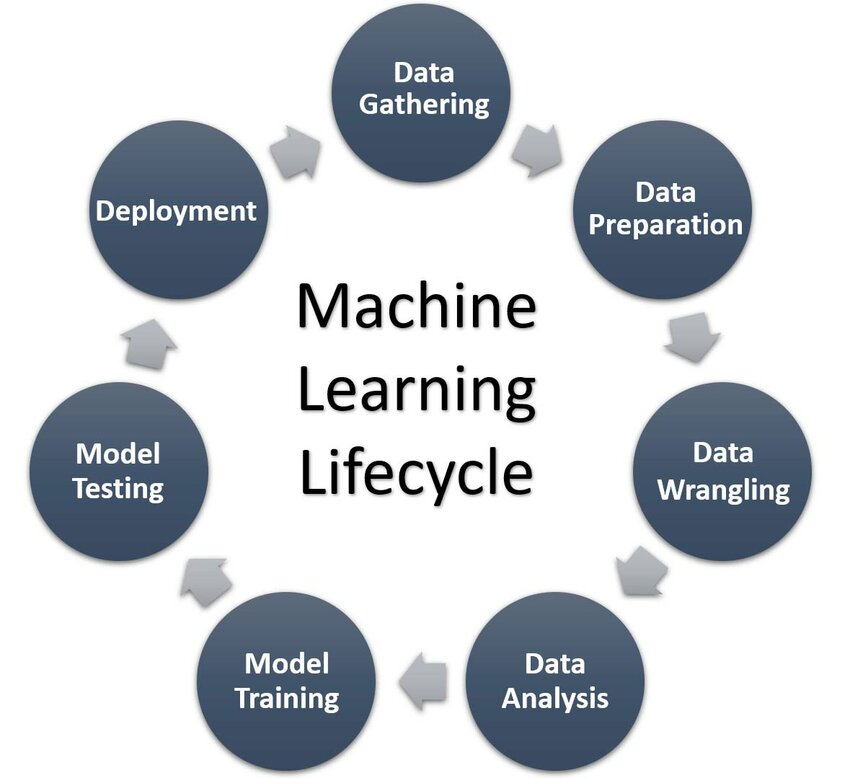



---


## k-Nearest Neighbors (k-NN)
----
### Theory Behind k-Nearest Neighbors

k-Nearest Neighbors (k-NN) is a simple, non-parametric classification algorithm that is based on the idea of similarity. It assumes that data points that are close to each other in the feature space are likely to belong to the same class. In essence, when given a new data point, k-NN looks at the 'k' closest data points (neighbors) and assigns the majority class among those neighbors to the new point.

**Key concepts:**
- **Instance-based Learning**: k-NN is an instance-based learning algorithm, meaning it doesn't create a model during training but simply stores the training data. Predictions are made directly from the data during inference.
- **Lazy Learner**: It is considered a lazy learner because it doesn't perform any generalization until it needs to classify a new data point.
- **Distance Metric**: The distance between data points is usually calculated using Euclidean distance, but other metrics like Manhattan or Minkowski distance can also be used.

### Steps in k-NN Algorithm

Here’s a simplified view of the steps involved in the k-NN algorithm:

1. **Select the Number of Neighbors (k)**:
   - Choose a value for k, which is the number of nearest neighbors to consider. Typically, an odd number is chosen to avoid ties in classification.

2. **Calculate the Distance**:
   - For a new data point, calculate the distance between it and every point in the training data. The most common distance metric used is Euclidean distance:

     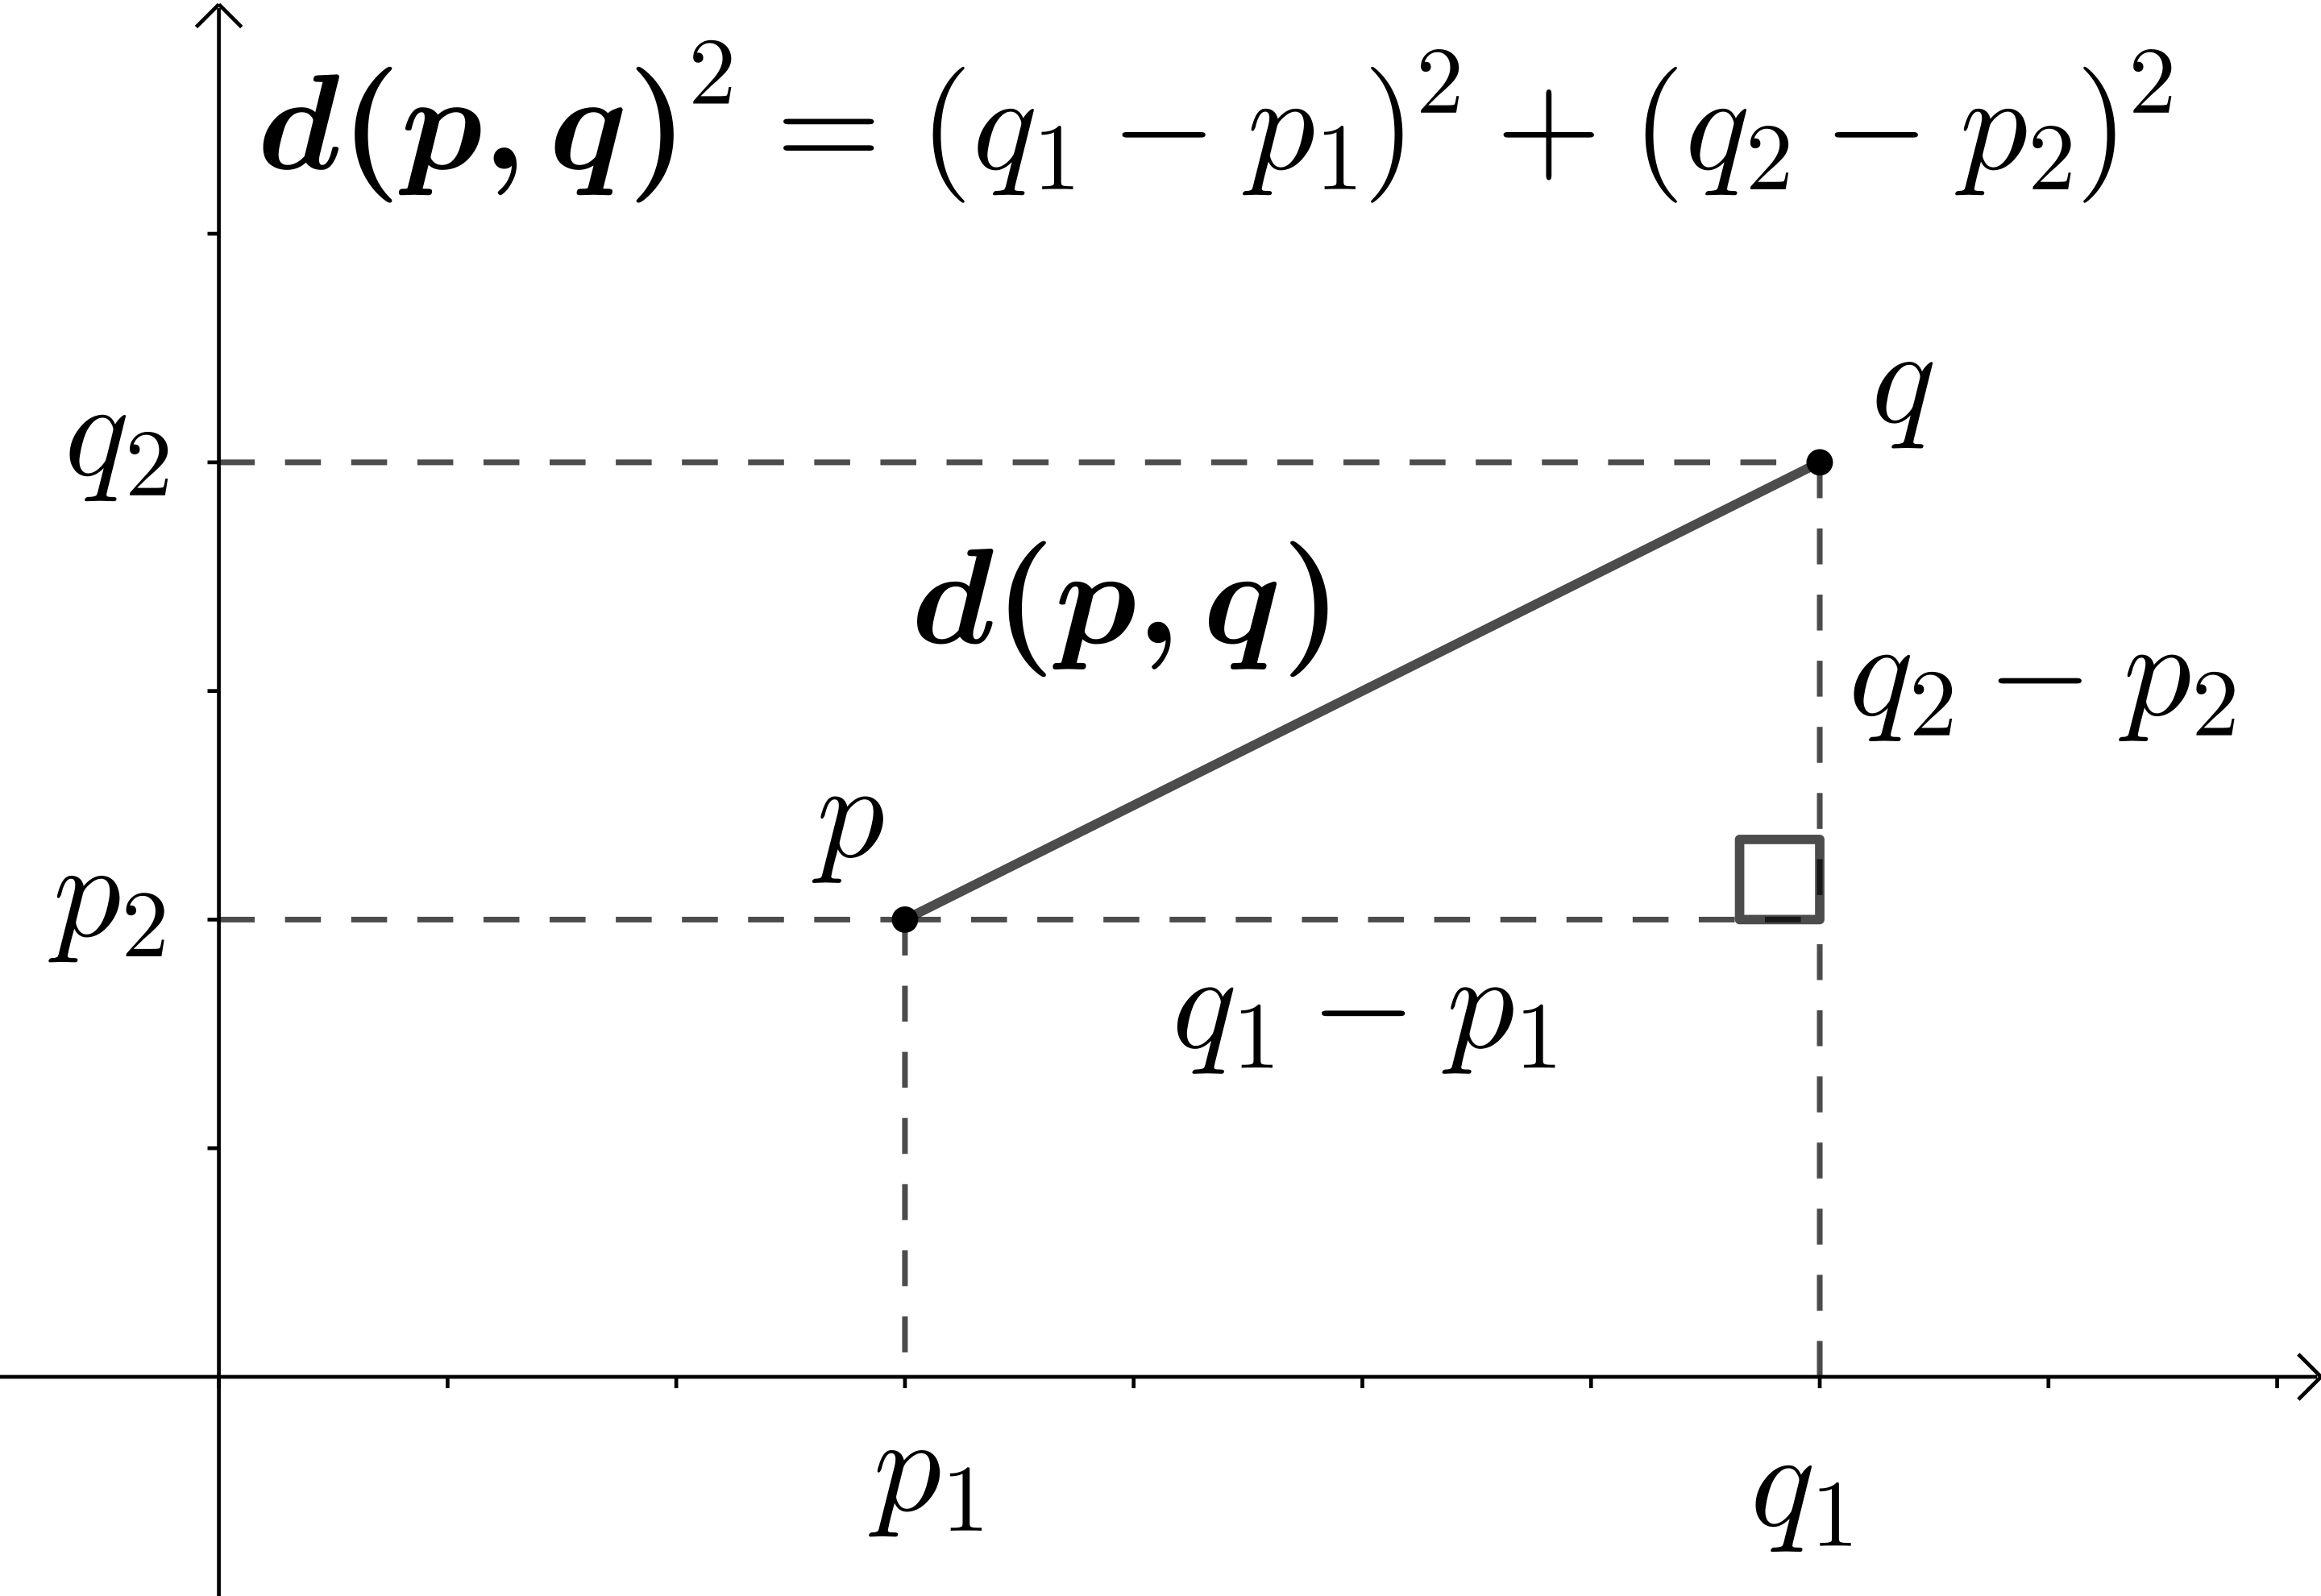


3. **Find the Nearest Neighbors**:
   - Sort all the distances and select the 'k' data points that are closest to the new data point.

4. **Assign a Class Label**:
   - Look at the labels of the nearest neighbors. The new data point is assigned the class that is most frequent among its k nearest neighbors (majority vote).

5. **Make a Prediction**:
   - Return the predicted label for the new data point.

---




![Alt Text](https://miro.medium.com/v2/resize:fit:1316/1*n9v1xsBi0bek98rqBnWGEg.gif)

![Alt Text](https://miro.medium.com/v2/resize:fit:1280/1*Gvwlpk2lGsxOHfxP-EZYhg.gif)

In the next section, we'll implement k-NN in Python and use it to classify a sample dataset.

Dataset Information:
Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


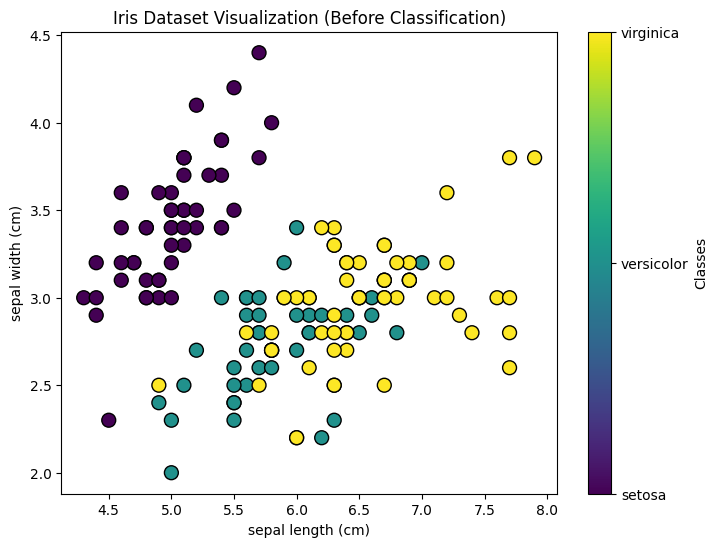

Accuracy of k-NN: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



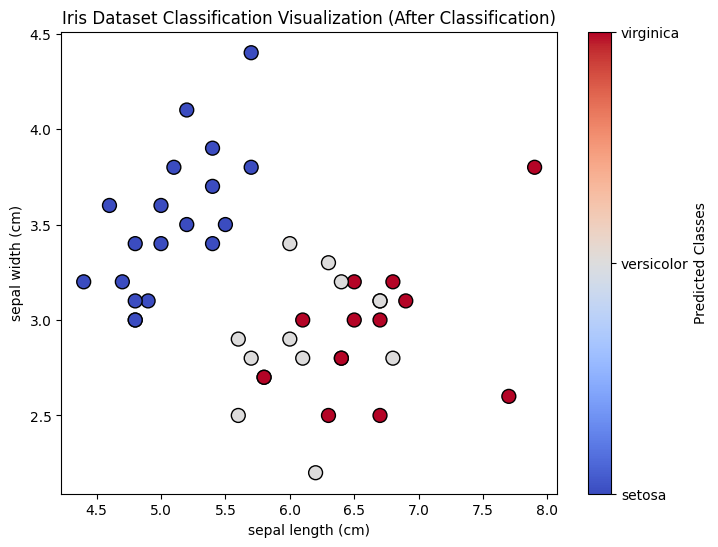

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


# Load the sample dataset (Iris dataset)
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels (target classes)

# Display dataset information
print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")
print(f"Class distribution: {np.bincount(y)}\n")  # Shows how many samples per class

# Converting the Iris dataset to a DataFrame for better visualization
iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                       columns=iris['feature_names'] + ['target'])
# Mapping target values to class names (0 -> Setosa, 1 -> Versicolor, 2 -> Virginica)
iris_df['target'] = iris_df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
# Display the first few rows of the dataset
display(iris_df)

# Visualizing the data before classification (using first two features for 2D plot)
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Iris Dataset Visualization (Before Classification)')
plt.xlabel(iris.feature_names[0])  # Feature 1 (sepal length)
plt.ylabel(iris.feature_names[1])  # Feature 2 (sepal width)
colorbar=plt.colorbar(label='Classes')
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(iris.target_names)  # Adding class labels to colorbar
plt.show()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Implementing k-Nearest Neighbors with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)  # Train the k-NN model on the training data

# Making predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print accuracy and classification report
print(f"Accuracy of k-NN: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_rep)

# Visualizing the data after classification (using first two features for 2D plot)
plt.figure(figsize=(8,6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Iris Dataset Classification Visualization (After Classification)')
plt.xlabel(iris.feature_names[0])  # Feature 1 (sepal length)
plt.ylabel(iris.feature_names[1])  # Feature 2 (sepal width)
colorbar=plt.colorbar(label='Predicted Classes')
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(iris.target_names)  # Adding class labels to colorbar
plt.show()


Dataset Information:
Number of samples: 500
Number of features: 2
Class distribution: [250 250]



,Feature 1,Feature 2,target
0,-0.469276,0.210118,Class 1
1,-0.164164,0.986075,Class 0
2,-0.471454,0.019974,Class 1
3,-0.670347,-0.657977,Class 0
4,-0.826468,0.594071,Class 0


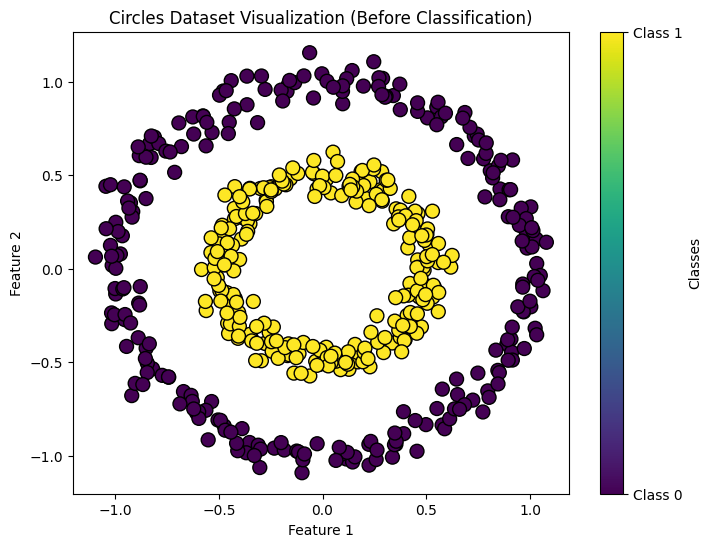

Accuracy of k-NN: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



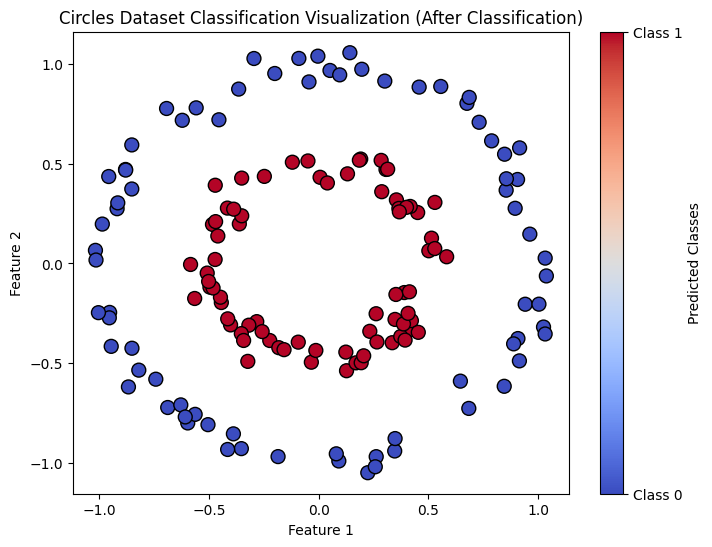

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import make_circles  # changes
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load the synthetic dataset (Circles dataset)
X, y = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)  # changes

# Display dataset information
print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Class distribution: {np.bincount(y)}\n")  # Shows how many samples per class

# Converting the circles dataset to a DataFrame for better visualization
circles_df = pd.DataFrame(data=np.c_[X, y], columns=['Feature 1', 'Feature 2', 'target'])
circles_df['target'] = circles_df['target'].map({0: 'Class 0', 1: 'Class 1'})
# Display the first few rows of the dataset
display(circles_df.head())

# Visualizing the data before classification
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Circles Dataset Visualization (Before Classification)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
colorbar = plt.colorbar(label='Classes')
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(['Class 0', 'Class 1'])
plt.show()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Implementing k-Nearest Neighbors with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)  # Train the k-NN model on the training data

# Making predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print accuracy and classification report
print(f"Accuracy of k-NN: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_rep)

# Visualizing the data after classification (using test data)
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Circles Dataset Classification Visualization (After Classification)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
colorbar = plt.colorbar(label='Predicted Classes')
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(['Class 0', 'Class 1'])
plt.show()


# **Advanced Version (Value of k)**


---

In the **k-Nearest Neighbors (k-NN)** algorithm, **k** refers to the number of nearest neighbors that the algorithm considers when making a classification or prediction. Here's how it works and how **k** affects the performance:

### What **k** Represents:
- When classifying a new data point, the algorithm looks at the **k** closest data points (neighbors) in the training dataset based on a distance metric (like Euclidean distance).
- The new data point is assigned to the majority class of these **k** neighbors.
  - For example, if **k=3**, the algorithm looks at the 3 closest neighbors. If two of them belong to class 'A' and one to class 'B', the new data point will be classified as class 'A' (majority voting).

### Effect of **k** on Model Behavior:

1. **Small k (e.g., k=1 or 2)**:
   - **Very sensitive to noise**: A small value of **k** means that the algorithm is making decisions based on very few neighbors, so even a single outlier (noisy data point) could drastically affect the classification.
   - **Low bias, high variance**: The model will fit the training data very closely, potentially leading to overfitting. It might perform well on the training set but poorly on unseen data.

2. **Large k (e.g., k=10 or more)**:
   - **More generalization**: As **k** increases, the algorithm considers a larger number of neighbors, making it less sensitive to individual noisy data points.
   - **High bias, low variance**: With too large **k**, the algorithm might become too generalized and overlook local patterns, which could result in underfitting and misclassifications, especially in complex datasets where classes are not well-separated.

### Choosing the Optimal **k**:
- **k** should generally be chosen based on cross-validation or experimenting with different values to see which yields the best accuracy or performance on the test set.
- **Odd values** of **k** are preferred in classification tasks to avoid ties in majority voting.

### Summary:
- A **small k** tends to lead to a model that is more flexible and closely fits the data, but it may be prone to overfitting.
- A **large k** leads to more generalized predictions, which may miss finer details in the data and result in underfitting.


IntSlider(value=3, continuous_update=False, description='k Value:', max=10, min=1)

Button(description='Run k-NN', style=ButtonStyle())

Output()

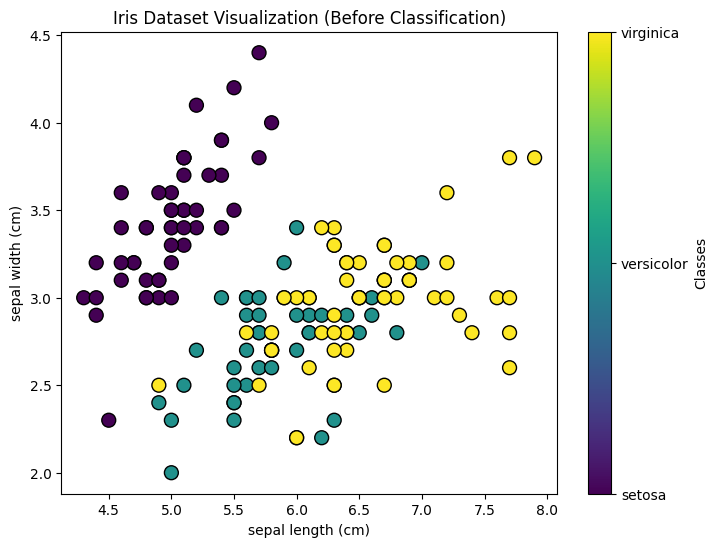

In [ ]:
# Re-import necessary libraries after the environment reset
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load the sample dataset (Iris dataset)
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels (target classes)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Creating a widget for selecting k value
k_slider = widgets.IntSlider(value=3, min=1, max=10, step=1, description='k Value:', continuous_update=False)

# Creating a button widget for running the classification
run_button = widgets.Button(description='Run k-NN')

# Output area to display plots and results
output = widgets.Output()

# Function to run k-NN with selected k value and display results
def run_knn(change):
    with output:
        clear_output()  # Clear previous output

        # Getting the selected k value from the slider
        k = k_slider.value

        # Implementing k-Nearest Neighbors with selected k
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)  # Train the k-NN model on the training data

        # Making predictions on the test set
        y_pred = knn.predict(X_test)

        # Evaluate the model's performance
        accuracy = accuracy_score(y_test, y_pred)
        classification_rep = classification_report(y_test, y_pred)

        # Display the accuracy and classification report
        print(f"Accuracy of k-NN with k={k}: {accuracy * 100:.2f}%")
        print("\nClassification Report:\n", classification_rep)

        # Visualizing the data after classification (using first two features for 2D plot)
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', edgecolor='k', s=100)
        plt.title(f'Iris Dataset Classification Visualization (After Classification with k={k})')
        plt.xlabel(iris.feature_names[0])  # Feature 1 (sepal length)
        plt.ylabel(iris.feature_names[1])  # Feature 2 (sepal width)
        colorbar = plt.colorbar(scatter, label='Predicted Classes')
        colorbar.set_ticks([0, 1, 2])
        colorbar.set_ticklabels(iris.target_names)  # Adding class labels to colorbar
        plt.show()

# Connecting the button to the function
run_button.on_click(run_knn)

# Displaying the widgets and output area
display(k_slider, run_button, output)

# Initial visualization (before classification)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Iris Dataset Visualization (Before Classification)')
plt.xlabel(iris.feature_names[0])  # Feature 1 (sepal length)
plt.ylabel(iris.feature_names[1])  # Feature 2 (sepal width)
colorbar = plt.colorbar(scatter, label='Classes')
colorbar.set_ticks([0, 1, 2])
colorbar.set_ticklabels(iris.target_names)  # Adding class labels to colorbar
plt.show()


# **Preprocessing of Data**


---



### 1. Load the Dataset
Load the dataset into a DataFrame for easier manipulation.

```python
import pandas as pd

# For the Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

# For the UCI Student Performance dataset, load it from a CSV file
# iris_df = pd.read_csv('student_performance.csv')
```

### 2. Explore the Data
Examine the dataset for basic understanding, including shape, data types, and missing values.

```python
# Display basic information
print(iris_df.info())

# Check for missing values
print(iris_df.isnull().sum())
```

### 3. Handle Missing Values
Decide how to deal with missing values. Common approaches include removing rows/columns or filling them with mean/median/mode.

```python
# Example: Fill missing values with mean for numeric columns
iris_df.fillna(iris_df.mean(), inplace=True)
```

### 4. Encode Categorical Variables
Convert categorical variables into numerical format using techniques like one-hot encoding or label encoding.

```python
# For the Iris dataset, the target variable is already numerical
# If using the UCI dataset, you may need to encode categorical variables
# Example for label encoding:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
iris_df['target'] = label_encoder.fit_transform(iris_df['target'])
```

### 5. Feature Scaling
Standardize or normalize features to bring them onto a similar scale. This is especially important for distance-based algorithms like k-NN.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = iris_df.iloc[:, :-1]  # Select feature columns
scaled_features = scaler.fit_transform(features)
```

### 6. Split the Data
Divide the dataset into training and testing sets to evaluate model performance.

```python
from sklearn.model_selection import train_test_split

X = scaled_features  # Features
y = iris_df['target']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

### 7. Final Check
Perform a final check to ensure that the dataset is ready for model training.

```python
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
```

### Summary
1. **Load the dataset**.
2. **Explore the data** for understanding.
3. **Handle missing values** appropriately.
4. **Encode categorical variables** if necessary.
5. **Scale the features** for consistency.
6. **Split the data** into training and testing sets.
7. **Perform a final check** to confirm readiness for modeling.

These steps should help ensure your dataset is well-prepared for modeling with k-NN, Decision Trees, or any other machine learning algorithm!

Dataset Information:
Number of samples: 20640
Number of features: 8
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


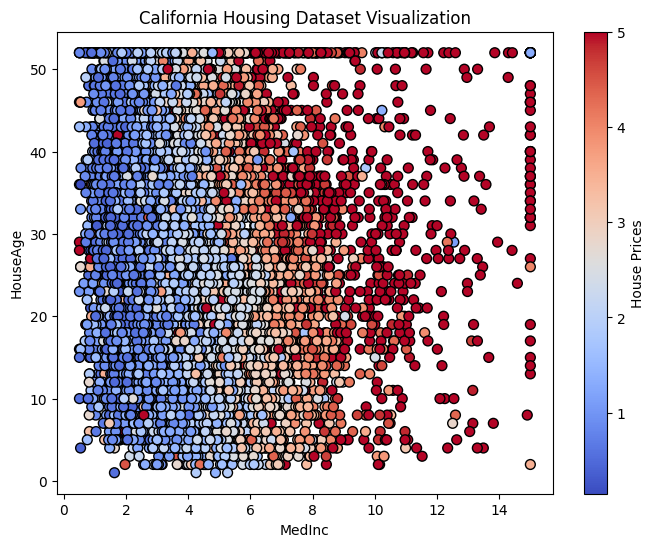

Mean Squared Error of k-NN Regressor: 1.20
R-squared score: 0.09


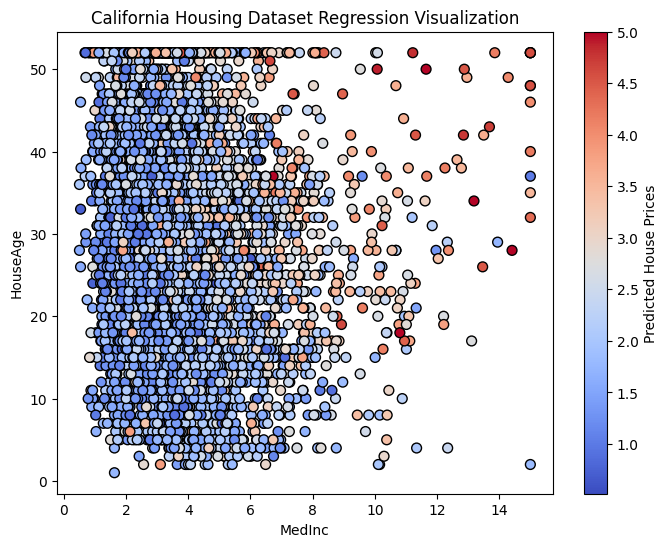

## **Decision Trees**

### Concept of Decision Trees in Supervised Learning

A **Decision Tree** is a tree-like model used in supervised learning, where each internal node represents a decision based on a feature, each branch represents the outcome of the decision, and each leaf node represents a class label (for classification tasks) or a value (for regression tasks).

Decision trees are simple yet powerful algorithms that split data based on feature values to make predictions. The model works by repeatedly splitting the dataset into subsets based on the feature that maximizes the distinction between different classes.

#### Steps in Decision Tree Creation:
1. The dataset is split based on a feature that provides the best separation between the classes.
2. This process continues recursively on each subset, creating deeper branches of the tree.
3. The recursion stops when further splitting does not improve the classification or when a stopping condition is met (e.g., maximum depth).

---

### Understanding Splitting Criteria

When building a decision tree, selecting the best feature to split the data is crucial. This is done using certain splitting criteria that measure the "impurity" or disorder in the dataset. Two common criteria are **Gini Index** and **Entropy**.

#### **1. Gini Index**
The **Gini Index** measures the impurity of a dataset. It is calculated as:

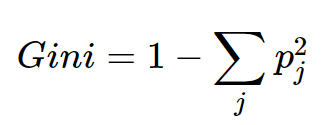

Where:
- \( C \) is the number of classes.
- \( p_j \) is the probability of a data point belonging to class \( j \).

A Gini Index of 0 indicates perfect classification (pure node), while a Gini Index close to 1 indicates high impurity.

#### **2. Entropy (Information Gain)**
**Entropy** measures the disorder or randomness in the data. It is used to calculate the **Information Gain**, which helps in deciding the best feature to split the data:

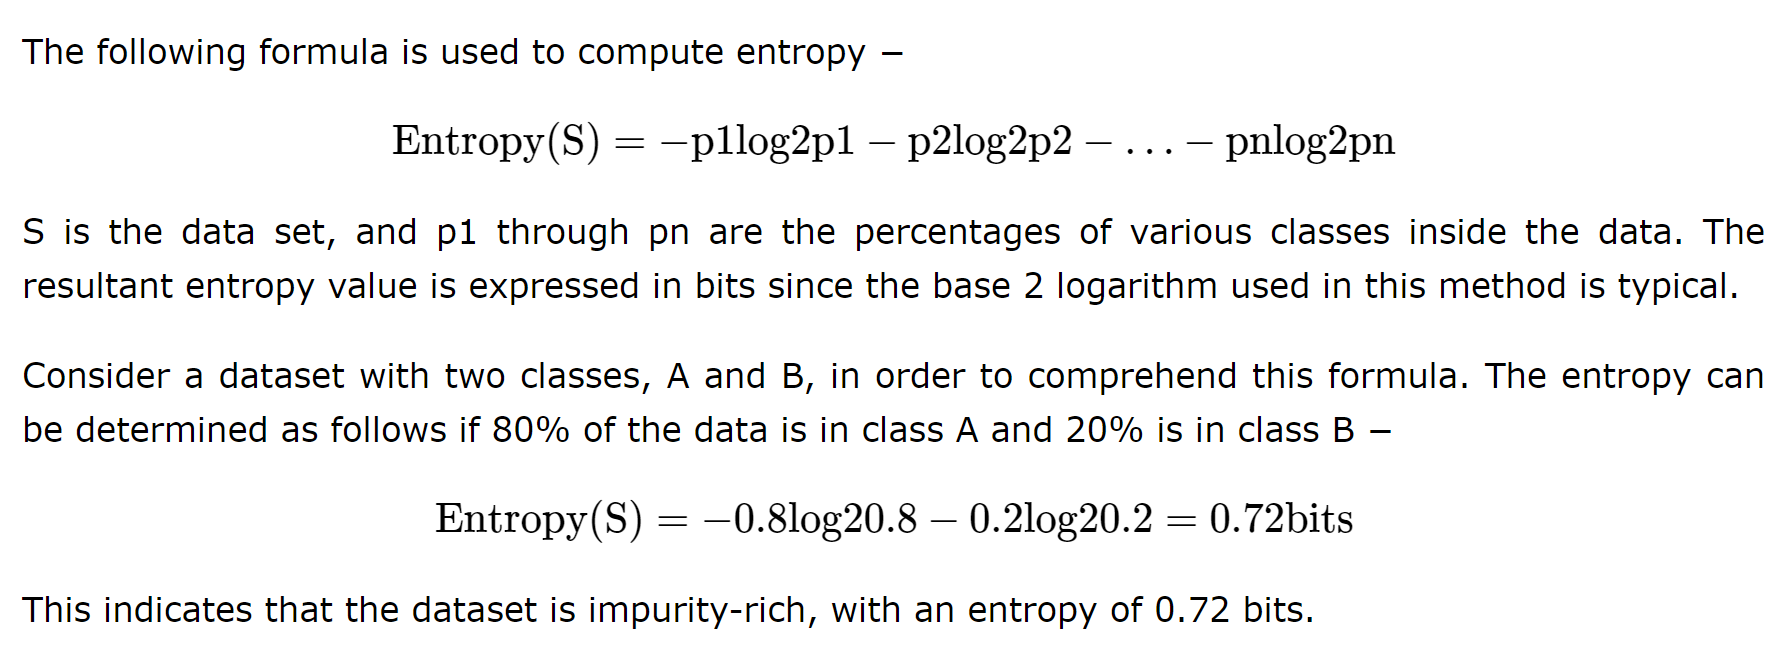


**Information Gain** is defined as the reduction in entropy after a dataset is split on a feature. Higher information gain means better feature for splitting.

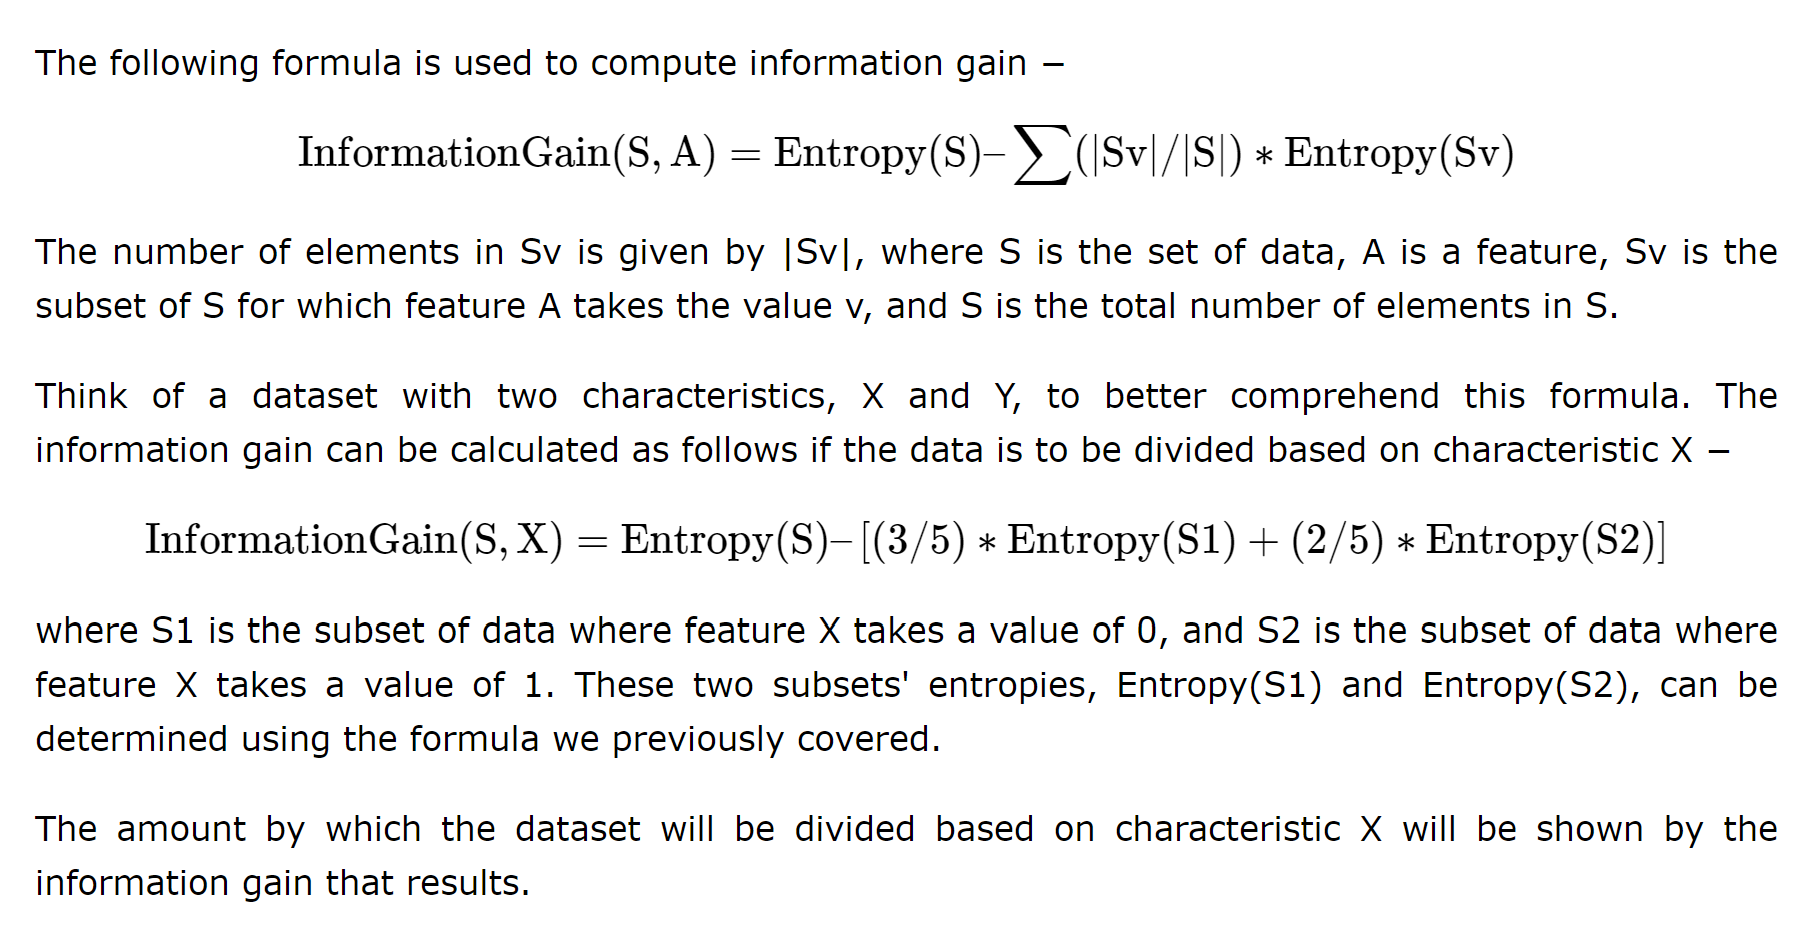

In decision trees, the feature with the highest **Information Gain** or the lowest **Gini Index** is chosen for splitting at each step.

---

In the next section, we will implement a decision tree classifier in Python and visualize the decision-making process.


Accuracy of Decision Tree: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



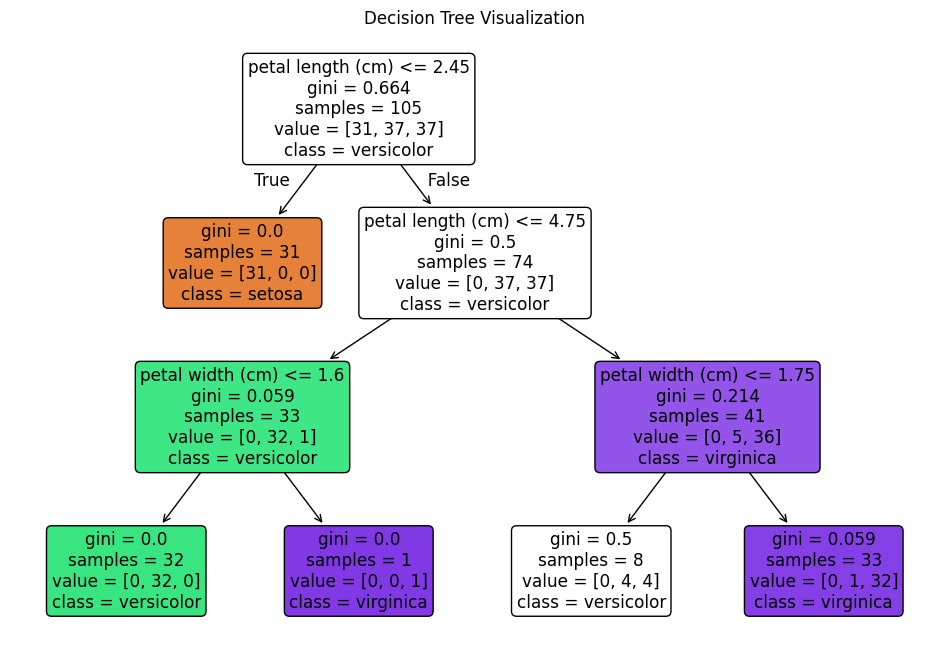

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Implementing Decision Tree Classifier
decision_tree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
decision_tree.fit(X_train, y_train)

# Making predictions on the test set
y_pred = decision_tree.predict(X_test)

# Evaluate the performance of the Decision Tree
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Display accuracy and classification report
print(f"Accuracy of Decision Tree: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_rep)

# Visualizing the Decision Tree
plt.figure(figsize=(12,8))
tree.plot_tree(decision_tree, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()


## Comparison of k-NN and Decision Trees

### Strengths and Weaknesses

#### k-Nearest Neighbors (k-NN)
**Strengths**:
- **Simplicity**: Easy to understand and implement.
- **No Training Phase**: k-NN is a lazy learner; it does not require a training phase, making it quick to set up.
- **Flexible**: Can be used for both classification and regression tasks.

**Weaknesses**:
- **Computationally Expensive**: Requires distance calculations for all training samples during prediction, which can be slow for large datasets.
- **Sensitive to Noise**: Outliers can significantly affect the model's performance.
- **Curse of Dimensionality**: Performance can degrade with high-dimensional data due to increased sparsity.

#### Decision Trees
**Strengths**:
- **Interpretability**: The tree structure makes it easy to understand and visualize decisions.
- **Handles Mixed Data Types**: Can work with both numerical and categorical data.
- **Non-Parametric**: Does not assume any distribution about the data.

**Weaknesses**:
- **Overfitting**: Decision trees can easily become too complex, leading to overfitting on training data.
- **Instability**: Small changes in the data can result in a completely different tree structure.
- **Biased Towards Dominant Classes**: Can be biased if one class is more prevalent.

---

### Suitable Use Cases for Each Model

#### k-NN
- **Recommendation Systems**: Identifying similar items based on user preferences.
- **Image Classification**: Classifying images by comparing pixel values.
- **Anomaly Detection**: Detecting outliers based on proximity to normal data points.

#### Decision Trees
- **Customer Segmentation**: Classifying customers based on features like age, income, and purchase behavior.
- **Medical Diagnosis**: Using patient data to classify diseases.
- **Risk Assessment**: Evaluating loan applications based on risk factors.

---

### Practical Application

Both k-NN and Decision Trees can be applied to various datasets. In practice, you might start with both models to see which one performs better on your specific task.

**Testing k-NN and Decision Tree Models on a Dataset**:
1. **Dataset Selection**: Choose a dataset relevant to your problem.
2. **Preprocessing**: Clean and prepare the data for modeling.
3. **Model Training**: Train both k-NN and Decision Tree models on the training set.
4. **Model Evaluation**: Use metrics like accuracy, precision, recall, and F1-score to compare the performance of both models.
5. **Visualization**: Analyze the decision boundaries of both models using appropriate plots.


